# Visualization of AE Embeddings

In [3]:
import os
import random
import pandas as pd
import torch
from tqdm import tqdm
if os.getcwd().endswith("notebooks"):
    os.chdir("../")

from src.embeddings.aggregation import EmbeddingAggregator
from src.embeddings.vis import plot_latent_trajectory, plot_embedding_map
from src.embeddings.models import MotionAutoencoder
from src.embeddings.dataset import WindowDatasetTCN
from src.embeddings.extract import EmbeddingExtractor

In [6]:
# Load processed data and construct dataset
processed_path = "data/processed"
paths = [os.path.join(processed_path, f) for f in os.listdir(processed_path) if f.endswith("10fps_processed.pkl")]

df_dict = {}
cols_to_keep = ['frame', 'hand_label', 'cx_smooth', 'cy_smooth']

with tqdm(total=len(paths), desc="Loading processed data") as pbar:
    for path in paths:
        vid = os.path.basename(path).replace("_10fps_processed.pkl", "")
        vid = vid.replace("hand_tracking_", "")
        df_dict[vid] = pd.read_pickle(path)[cols_to_keep]
        pbar.update(1)

dataset = WindowDatasetTCN(
    df_dict=df_dict,
    window_size=30,
    step_size=10,
    hand="Right", 
    fps=10,
)

Loading processed data:   0%|          | 0/86 [00:00<?, ?it/s]

Processing Right Hand Windows: 100%|██████████| 86/86 [00:00<00:00, 144.63it/s]


Computing robust scaling statistics from training data...


In [8]:
seq = torch.tensor(list(dataset.data.values())[0], dtype=torch.float32, device="cpu")
seq_name = list(dataset.data.keys())[0]

In [11]:
# import saved AE model
feature_dim = 7
latent_dim = 16
model_path = "results/models/motion_autoencoder.pth"

state_dict = torch.load(model_path)

ae = MotionAutoencoder(feature_dim, latent_dim=latent_dim)
ae.load_state_dict(state_dict)

ae.eval()

/var/folders/sj/219f9qbn3y15yynshcyrrp3c0000gn/T/ipykernel_11298/3042440038.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path)


MotionAutoencoder(
  (encoder): Sequential(
    (0): Conv1d(6, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(4,), dilation=(2,))
    (3): ReLU()
  )
  (fc_enc): Linear(in_features=32, out_features=16, bias=True)
  (fc_dec): Linear(in_features=16, out_features=32, bias=True)
  (decoder): Sequential(
    (0): Conv1d(32, 16, kernel_size=(5,), stride=(1,), padding=(4,), dilation=(2,))
    (1): ReLU()
    (2): Conv1d(16, 6, kernel_size=(5,), stride=(1,), padding=(2,))
  )
  (time_proj): Linear(in_features=1, out_features=32, bias=True)
)

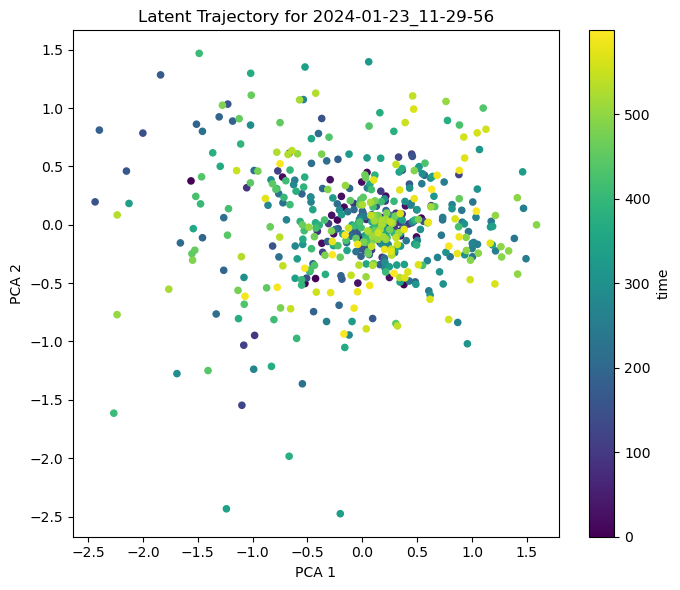

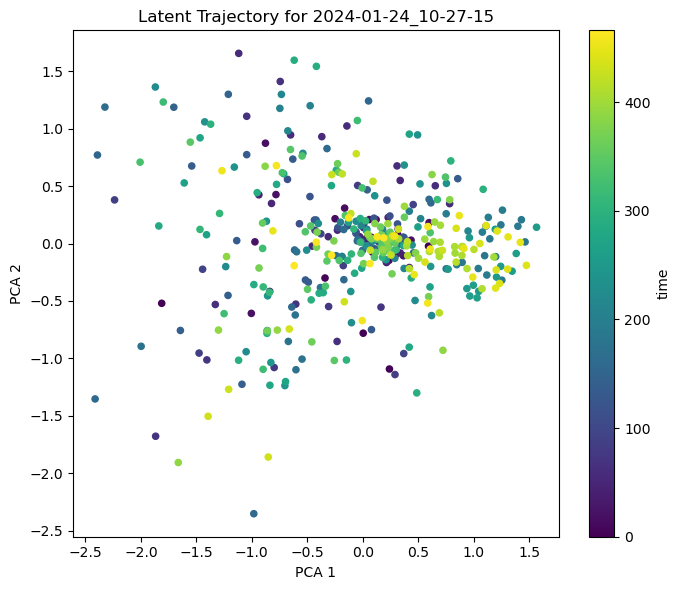

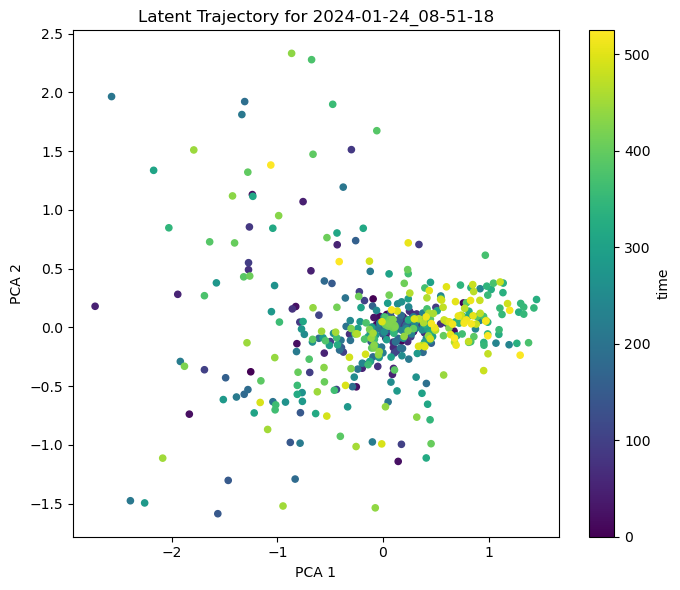

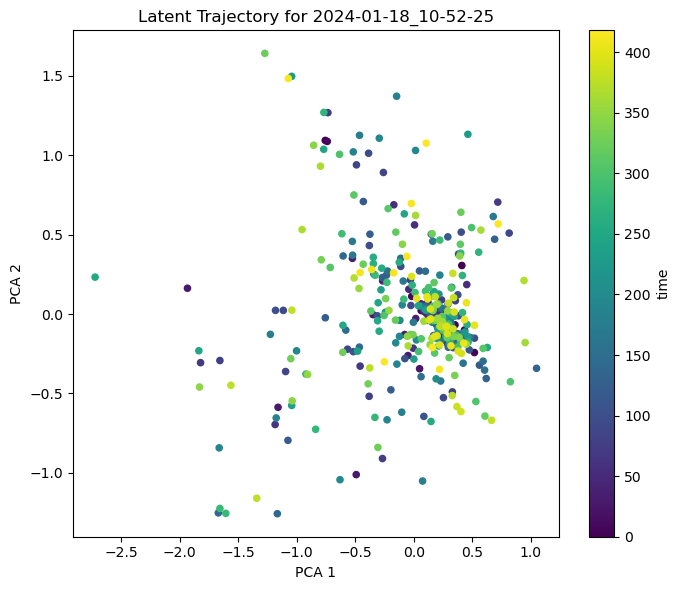

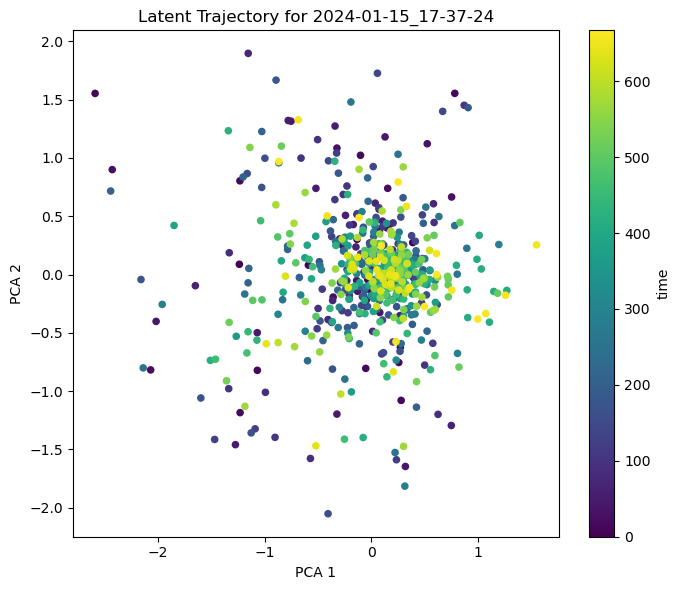

In [12]:
extractor = EmbeddingExtractor(ae, window_size=30, step_size=10, device="cpu")

n = 5
idx = random.sample(range(86), n)

for i in idx:
    seq = torch.tensor(list(dataset.data.values())[i], dtype=torch.float32, device="cpu")
    seq_name = list(dataset.data.keys())[i]
    embeddings = extractor.extract_embeddings(seq)[0]
    plot_latent_trajectory(embeddings, title=f"Latent Trajectory for {seq_name}")

# Aggregated Video Level Embeddings

In [13]:
aggregator = EmbeddingAggregator(method="mean_std")

embeddings_dict = {}

with tqdm(total=len(paths), desc="Extracting aggregated embeddings") as pbar:
    for i in range(len(paths)):
        seq = torch.tensor(list(dataset.data.values())[i], dtype=torch.float32, device="cpu")
        seq_name = list(dataset.data.keys())[i]
        embeddings = extractor.extract_embeddings(seq)[0]
        embedding = aggregator(embeddings)
        embeddings_dict[seq_name] = embedding
        pbar.update(1)

Extracting aggregated embeddings: 100%|██████████| 86/86 [00:20<00:00,  4.26it/s]


In [14]:
import pandas as pd
import numpy as np

def make_scores_unique(df, score_column='QRS_Overal', tolerance=1e-8):
    """
    Identifies duplicate values in the specified score column and adds a 
    small, unique, random jitter to each tied score to ensure uniqueness.

    Args:
        df (pd.DataFrame): The input DataFrame.
        score_column (str): The name of the column containing the scores.
        tolerance (float): The maximum magnitude of the random jitter to add. 

    Returns:
        pd.DataFrame: The DataFrame with the score column made unique.
    """
    
    # 1. Identify groups of duplicate scores
    # .duplicated(keep=False) marks ALL occurrences of a duplicate value as True
    duplicates = df[df.duplicated(subset=[score_column], keep=False)]

    if duplicates.empty:
        print("Scores are already unique. No modification needed.")
        return df

    # Create a copy to modify without warnings
    df_unique = df.copy()

    # 2. Iterate through groups of identical scores
    for score, group in duplicates.groupby(score_column):
        
        # Determine how many unique jitters are needed for this group
        n_duplicates = len(group)
        
        # Generate n unique, small random numbers (jitter)
        # Using uniform distribution within [-tolerance, +tolerance]
        # and sorting them to ensure a consistent, but still random, order 
        # for the perturbation within the group.
        jitter = np.sort(np.random.uniform(-tolerance, tolerance, size=n_duplicates))
        
        # Get the indices of the original rows
        indices_to_jitter = group.index
        
        # Apply the jitter to the original score
        df_unique.loc[indices_to_jitter, score_column] += jitter
        
    print(f"Successfully made {len(duplicates)} scores unique using jitter.")
    return df_unique

In [15]:
df = pd.read_csv("data/scores/merged_scores.csv")[['Vid_Name', 'QRS_Overal']]

# 1. Convert embeddings_dict items to a DataFrame
embeddings_df = pd.DataFrame(
    list(embeddings_dict.items()), 
    columns=['Vid_Name', 'Embedding']
)

# 2. Merge the DataFrames on the common key 'Vid_Name'
# This automatically handles missing keys and is very fast.
merged_df = pd.merge(df, embeddings_df, on='Vid_Name', how='inner')
merged_df_unique = make_scores_unique(merged_df)

# 3. Create the final dictionary from the merged DataFrame
embeddings_dict_scores = dict(zip(merged_df_unique['QRS_Overal'], merged_df_unique['Embedding']))

len(embeddings_dict_scores)

Successfully made 33 scores unique using jitter.


83

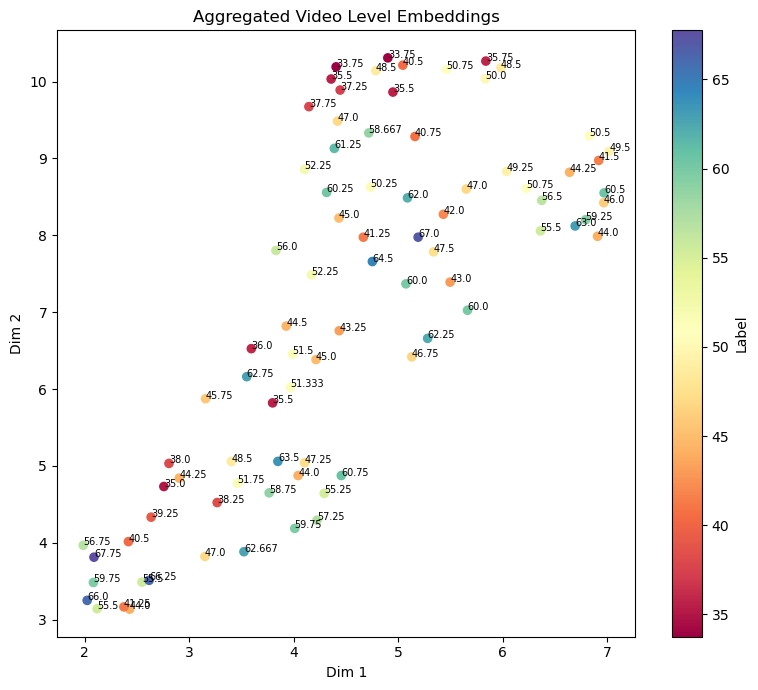

In [17]:
plot_embedding_map(embeddings_dict_scores, labels=list(embeddings_dict_scores.keys()),method='umap', title="Aggregated Video Level Embeddings")

In [20]:
df = pd.read_csv("data/scores/merged_scores.csv")[['Vid_Name', 'Case_Number', 'QRS_Overal']]

# 1. Convert embeddings_dict items to a DataFrame
embeddings_df = pd.DataFrame(
    list(embeddings_dict.items()), 
    columns=['Vid_Name', 'Embedding']
)

# 2. Merge the DataFrames on the common key 'Vid_Name'
# This automatically handles missing keys and is very fast.
merged_df = pd.merge(df, embeddings_df, on='Vid_Name', how='inner')
merged_df_unique = make_scores_unique(merged_df, score_column='Case_Number')

# 3. Create the final dictionary from the merged DataFrame
embeddings_dict_scores = dict(zip(merged_df_unique['Case_Number'], merged_df_unique['Embedding']))

len(embeddings_dict_scores)

Successfully made 83 scores unique using jitter.


/var/folders/sj/219f9qbn3y15yynshcyrrp3c0000gn/T/ipykernel_98462/3497377400.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.99999999 0.99999999 0.99999999 0.99999999 0.99999999 0.99999999
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.00000001
 1.00000001 1.00000001 1.00000001 1.00000001]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_unique.loc[indices_to_jitter, score_column] += jitter


83

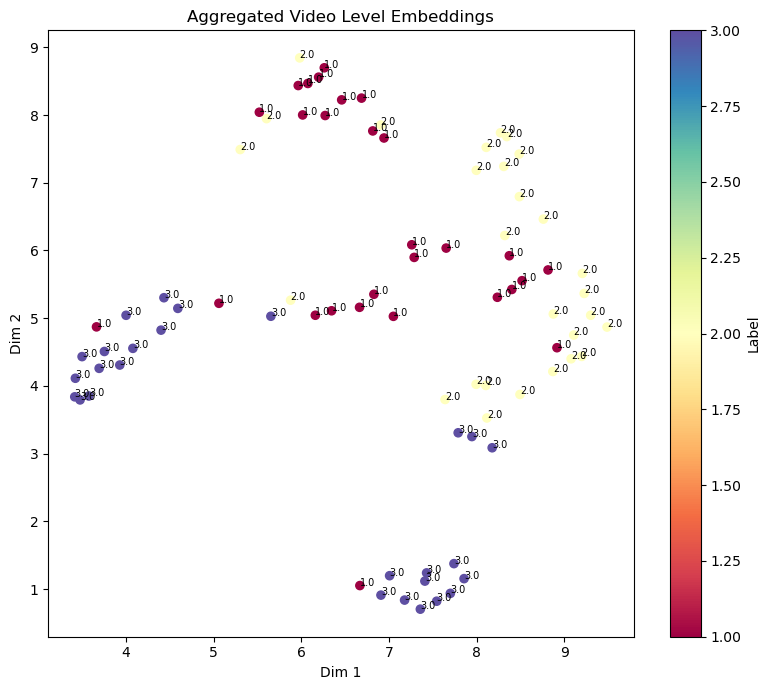

In [24]:
plot_embedding_map(embeddings_dict_scores, labels=list(embeddings_dict_scores.keys()),method='umap', title="Aggregated Video Level Embeddings")